# 2. Алгоритм Apriori — пошук асоціативних правил

**Алгоритм Apriori** — класичний алгоритм для пошуку частих наборів елементів та генерації асоціативних правил.

**Ключові метрики:**
- **Support** — частка транзакцій, що містять набір елементів
- **Confidence** — умовна ймовірність P(B|A)
- **Lift** — сила зв'язку між елементами (>1 = позитивний зв'язок)

**Мета:** знайти найцікавіші асоціативні правила між аудіо-характеристиками треків Spotify та визначити 4 пари атрибутів з найвищим lift для подальшої кластеризації.

In [1]:
import sys, os, json, time
sys.path.insert(0, os.path.abspath('.'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings
warnings.filterwarnings('ignore')

from src.config import (
    BINNED_PATH, RESULTS_DIR, TOP_PAIRS_PATH, APRIORI_TIME_PATH,
    ASSOC_FEATURES, GENRE_COL, MIN_SUPPORT, MIN_LIFT, N_TOP_PAIRS
)

sns.set_style('whitegrid')
print(f"MIN_SUPPORT={MIN_SUPPORT}, MIN_LIFT={MIN_LIFT}, N_TOP_PAIRS={N_TOP_PAIRS}")

MIN_SUPPORT=0.03, MIN_LIFT=1.0, N_TOP_PAIRS=4


In [2]:
df = pd.read_csv(BINNED_PATH)
print(f"Форма даних: {df.shape}")
print(f"Стовпці: {list(df.columns)}")
print()
for col in df.columns:
    print(f"  {col}: {sorted(df[col].unique())}")
df.head(10)

Форма даних: (89741, 7)
Стовпці: ['danceability', 'energy', 'valence', 'acousticness', 'speechiness', 'loudness', 'track_genre']

  danceability: ['High', 'Low', 'Medium']
  energy: ['High', 'Low', 'Medium']
  valence: ['High', 'Low', 'Medium']
  acousticness: ['High', 'Low', 'Medium']
  speechiness: ['High', 'Low', 'Medium']
  loudness: ['Loud', 'Medium', 'Quiet']
  track_genre: ['Other', 'acoustic', 'afrobeat', 'alt-rock', 'ambient', 'black-metal', 'bluegrass', 'breakbeat', 'cantopop', 'chicago-house', 'disney', 'forro', 'heavy-metal', 'sleep', 'study', 'tango']


,danceability,energy,valence,acousticness,speechiness,loudness,track_genre
0,High,Medium,High,Low,Low,Loud,acoustic
1,Medium,Low,Low,High,Low,Medium,acoustic
2,Medium,Medium,Low,Low,Low,Loud,acoustic
3,Low,Low,Low,High,Low,Medium,acoustic
4,Medium,Medium,Low,Medium,Low,Loud,acoustic
5,High,Medium,High,Low,Low,Loud,acoustic
6,Medium,Low,Low,High,Low,Loud,acoustic
7,High,Medium,High,Medium,Low,Loud,acoustic
8,Medium,Medium,High,Low,Low,Loud,acoustic
9,Medium,Medium,Low,Medium,Low,Loud,acoustic


## 2.1 One-Hot кодування

Для алгоритму Apriori потрібна бінарна матриця (boolean). Кожне значення категоріального стовпця стає окремим стовпцем: наприклад, `danceability_High`, `energy_Low`, `track_genre_pop` тощо.

In [3]:
df_oh = pd.get_dummies(df, columns=df.columns.tolist(), dtype=bool, prefix_sep='_')
print(f"One-hot форма: {df_oh.shape}")
print(f"Стовпці ({len(df_oh.columns)}): {list(df_oh.columns)}")
df_oh.head()

One-hot форма: (89741, 34)
Стовпці (34): ['danceability_High', 'danceability_Low', 'danceability_Medium', 'energy_High', 'energy_Low', 'energy_Medium', 'valence_High', 'valence_Low', 'valence_Medium', 'acousticness_High', 'acousticness_Low', 'acousticness_Medium', 'speechiness_High', 'speechiness_Low', 'speechiness_Medium', 'loudness_Loud', 'loudness_Medium', 'loudness_Quiet', 'track_genre_Other', 'track_genre_acoustic', 'track_genre_afrobeat', 'track_genre_alt-rock', 'track_genre_ambient', 'track_genre_black-metal', 'track_genre_bluegrass', 'track_genre_breakbeat', 'track_genre_cantopop', 'track_genre_chicago-house', 'track_genre_disney', 'track_genre_forro', 'track_genre_heavy-metal', 'track_genre_sleep', 'track_genre_study', 'track_genre_tango']


,danceability_High,danceability_Low,danceability_Medium,energy_High,energy_Low,energy_Medium,valence_High,valence_Low,valence_Medium,acousticness_High,...,track_genre_bluegrass,track_genre_breakbeat,track_genre_cantopop,track_genre_chicago-house,track_genre_disney,track_genre_forro,track_genre_heavy-metal,track_genre_sleep,track_genre_study,track_genre_tango
0,True,False,False,False,False,True,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,True,False,True,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False
2,False,False,True,False,False,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,True,False,False,True,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False
4,False,False,True,False,False,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


## 2.2 Пошук частих наборів (Apriori)

Запускаємо алгоритм Apriori з мінімальним порогом підтримки `MIN_SUPPORT` для знаходження частих наборів елементів.

In [4]:
start = time.time()
frequent = apriori(df_oh, min_support=MIN_SUPPORT, use_colnames=True)
apriori_time = time.time() - start

print(f"Знайдено {len(frequent)} частих наборів (min_support={MIN_SUPPORT})")
print(f"Час виконання: {apriori_time:.4f} сек")
print()

frequent_sorted = frequent.sort_values('support', ascending=False)
print("Топ-15 частих наборів за support:")
frequent_sorted.head(15)

Знайдено 855 частих наборів (min_support=0.03)
Час виконання: 0.3781 сек

Топ-15 частих наборів за support:


,support,itemsets
12,0.964442,frozenset({speechiness_Low})
16,0.833164,frozenset({track_genre_Other})
114,0.799222,"frozenset({track_genre_Other, speechiness_Low})"
13,0.731672,frozenset({loudness_Loud})
111,0.707581,"frozenset({loudness_Loud, speechiness_Low})"
115,0.627194,"frozenset({track_genre_Other, loudness_Loud})"
364,0.603994,"frozenset({track_genre_Other, loudness_Loud, s..."
10,0.595525,frozenset({acousticness_Low})
103,0.579278,"frozenset({acousticness_Low, speechiness_Low})"
2,0.573428,frozenset({danceability_Medium})


## 2.3 Генерація асоціативних правил

Генеруємо правила з метрикою lift >= `MIN_LIFT`. Lift > 1 означає позитивний зв'язок між елементами правила.

In [5]:
rules = association_rules(frequent, metric='lift', min_threshold=MIN_LIFT, num_itemsets=len(frequent))
rules = rules.sort_values('lift', ascending=False)
print(f"Згенеровано {len(rules)} правил (lift >= {MIN_LIFT})")
print()
print("Топ-20 правил за lift:")
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(20)

Згенеровано 9930 правил (lift >= 1.0)

Топ-20 правил за lift:


,antecedents,consequents,support,confidence,lift
3084,"frozenset({loudness_Quiet, speechiness_Low})","frozenset({valence_Low, energy_Low})",0.031223,0.763904,8.018893
3089,"frozenset({valence_Low, energy_Low})","frozenset({loudness_Quiet, speechiness_Low})",0.031223,0.327758,8.018893
681,frozenset({loudness_Quiet}),"frozenset({valence_Low, energy_Low})",0.031401,0.753073,7.905199
680,"frozenset({valence_Low, energy_Low})",frozenset({loudness_Quiet}),0.031401,0.329629,7.905199
3090,frozenset({loudness_Quiet}),"frozenset({speechiness_Low, valence_Low, energ...",0.031223,0.748797,7.903767
3083,"frozenset({speechiness_Low, valence_Low, energ...",frozenset({loudness_Quiet}),0.031223,0.329570,7.903767
4788,"frozenset({speechiness_Low, valence_Low, energ...","frozenset({danceability_Low, acousticness_High})",0.034644,0.365679,7.865860
4805,"frozenset({danceability_Low, acousticness_High})","frozenset({speechiness_Low, valence_Low, energ...",0.034644,0.745206,7.865860
4797,"frozenset({valence_Low, energy_Low})","frozenset({danceability_Low, acousticness_High...",0.034644,0.363668,7.848955
4796,"frozenset({danceability_Low, acousticness_High...","frozenset({valence_Low, energy_Low})",0.034644,0.747715,7.848955


## 2.4 Визначення Top-4 пар атрибутів

Для кожного правила визначаємо батьківські атрибути (наприклад, `danceability_High` -> `danceability`), знаходимо унікальні пари та обираємо ті, що мають найвищий lift. Пари з жанрами виключаємо — жанр використовуватимемо окремо.

In [6]:
ALL_FEATURES = ASSOC_FEATURES + ['tempo', 'loudness', GENRE_COL]

def get_parent_attr(col_name):
    """Витягує назву батьківського атрибута з one-hot стовпця."""
    for feat in sorted(ALL_FEATURES, key=len, reverse=True):
        if col_name.startswith(feat + '_'):
            return feat
    return col_name

pair_lifts = {}
pair_rules = {}
for _, row in rules.iterrows():
    ante_attrs = set(get_parent_attr(c) for c in row['antecedents'])
    cons_attrs = set(get_parent_attr(c) for c in row['consequents'])
    all_attrs = ante_attrs | cons_attrs
    if len(all_attrs) >= 2:
        for a1 in all_attrs:
            for a2 in all_attrs:
                if a1 < a2:
                    pair = (a1, a2)
                    if GENRE_COL not in pair:
                        if pair not in pair_lifts or row['lift'] > pair_lifts[pair]:
                            pair_lifts[pair] = row['lift']
                            pair_rules[pair] = row

top_sorted = sorted(pair_lifts.items(), key=lambda x: x[1], reverse=True)
top_pairs = top_sorted[:N_TOP_PAIRS]
pairs_list = [list(p) for p, _ in top_pairs]

os.makedirs(RESULTS_DIR, exist_ok=True)
with open(TOP_PAIRS_PATH, 'w') as f:
    json.dump(pairs_list, f, indent=2)

print("=" * 70)
print(f"TOP-{N_TOP_PAIRS} ПАР АТРИБУТІВ ЗА LIFT (для кластеризації)")
print("=" * 70)
for i, (pair, lift) in enumerate(top_pairs):
    r = pair_rules[pair]
    ant = ', '.join(str(x) for x in r['antecedents'])
    con = ', '.join(str(x) for x in r['consequents'])
    print(f"\n{i+1}. {pair[0]} + {pair[1]}")
    print(f"   Найсильніше правило: {ant} -> {con}")
    print(f"   Lift={lift:.4f}, Support={r['support']:.4f}, Confidence={r['confidence']:.4f}")

print(f"\nЗбережено {TOP_PAIRS_PATH}: {pairs_list}")

TOP-4 ПАР АТРИБУТІВ ЗА LIFT (для кластеризації)

1. loudness + speechiness
   Найсильніше правило: loudness_Quiet, speechiness_Low -> valence_Low, energy_Low
   Lift=8.0189, Support=0.0312, Confidence=0.7639

2. loudness + valence
   Найсильніше правило: loudness_Quiet, speechiness_Low -> valence_Low, energy_Low
   Lift=8.0189, Support=0.0312, Confidence=0.7639

3. speechiness + valence
   Найсильніше правило: loudness_Quiet, speechiness_Low -> valence_Low, energy_Low
   Lift=8.0189, Support=0.0312, Confidence=0.7639

4. energy + loudness
   Найсильніше правило: loudness_Quiet, speechiness_Low -> valence_Low, energy_Low
   Lift=8.0189, Support=0.0312, Confidence=0.7639

Збережено F:\University\Магістр\Data Mining\Lab2-Data-Mining-2026\results\top_pairs.json: [['loudness', 'speechiness'], ['loudness', 'valence'], ['speechiness', 'valence'], ['energy', 'loudness']]


## 2.5 Правила з жанрами

Фільтруємо правила, де `track_genre` з'являється в антецеденті або консеквенті. Такі правила показують зв'язок між аудіо-характеристиками та музичними жанрами (наприклад, "висока енергія + швидкий темп => EDM").

In [7]:
def has_genre(itemset):
    return any(get_parent_attr(item) == GENRE_COL for item in itemset)

genre_mask = rules['antecedents'].apply(has_genre) | rules['consequents'].apply(has_genre)
genre_rules = rules[genre_mask].sort_values('lift', ascending=False)

print(f"Правил з жанрами: {len(genre_rules)}")
print()
print("Топ-20 найцікавіших правил з жанрами (за lift):")
genre_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(20)

Правил з жанрами: 6328

Топ-20 найцікавіших правил з жанрами (за lift):


,antecedents,consequents,support,confidence,lift
9253,"frozenset({acousticness_High, loudness_Medium,...","frozenset({track_genre_Other, energy_Low})",0.034499,0.609809,5.609355
9284,"frozenset({track_genre_Other, energy_Low})","frozenset({acousticness_High, loudness_Medium,...",0.034499,0.317343,5.609355
9267,"frozenset({acousticness_High, loudness_Medium,...","frozenset({track_genre_Other, speechiness_Low,...",0.034499,0.589490,5.512285
9270,"frozenset({track_genre_Other, speechiness_Low,...","frozenset({acousticness_High, loudness_Medium,...",0.034499,0.322601,5.512285
9243,"frozenset({valence_Low, track_genre_Other, aco...",frozenset({energy_Low}),0.034499,0.813025,5.468573
9294,frozenset({energy_Low}),"frozenset({valence_Low, track_genre_Other, aco...",0.034499,0.232049,5.468573
6843,"frozenset({acousticness_High, loudness_Medium,...","frozenset({track_genre_Other, energy_Low})",0.034622,0.591584,5.441713
6852,"frozenset({track_genre_Other, energy_Low})","frozenset({acousticness_High, loudness_Medium,...",0.034622,0.318471,5.441713
8737,"frozenset({track_genre_Other, acousticness_Hig...","frozenset({danceability_Medium, energy_Low})",0.036561,0.448592,5.370474
8766,"frozenset({danceability_Medium, energy_Low})","frozenset({track_genre_Other, acousticness_Hig...",0.036561,0.437700,5.370474


## 2.6 Візуалізація

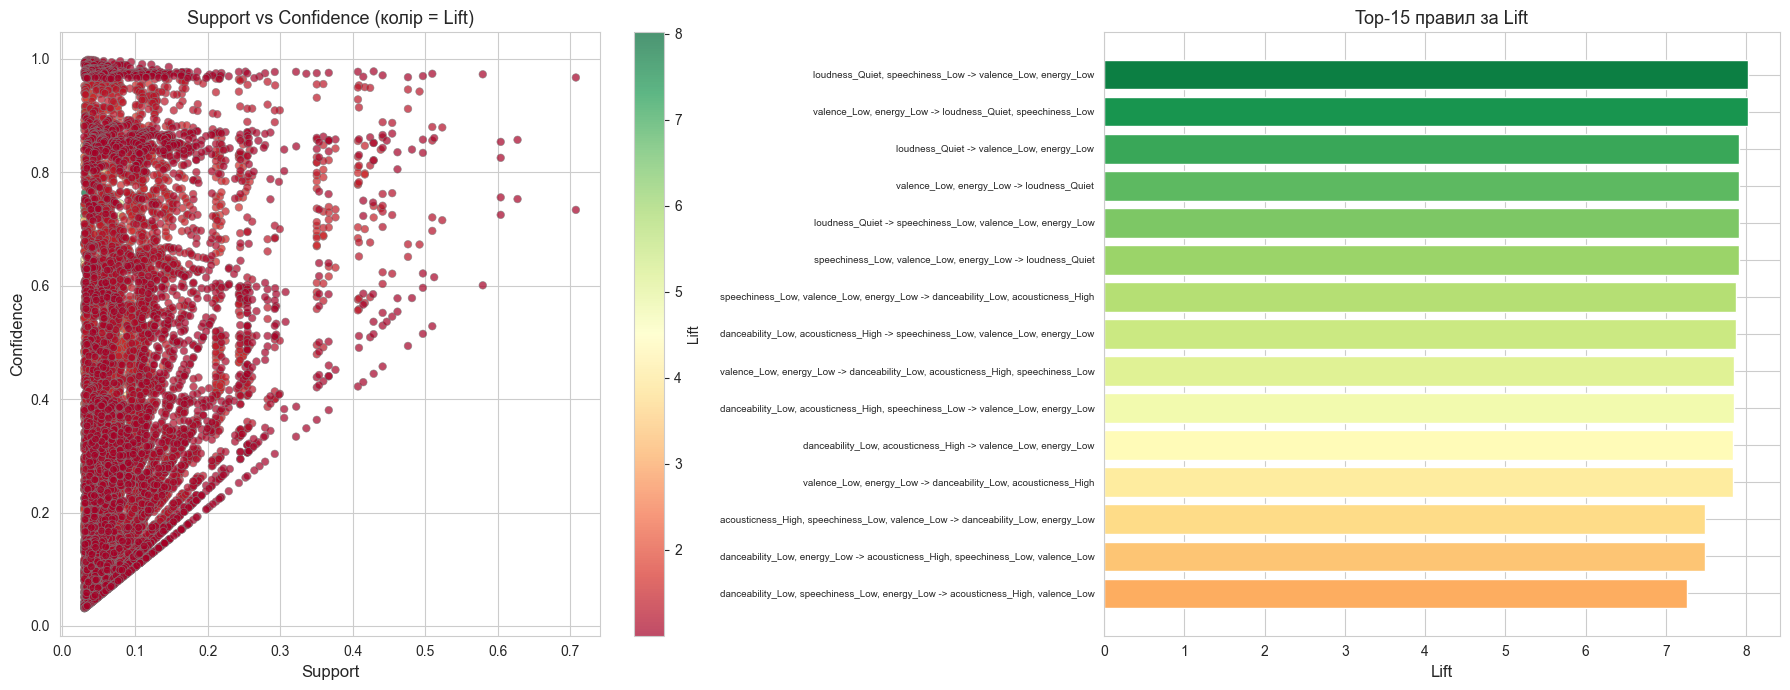

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Лівий графік: Support vs Confidence (колір = Lift) ---
scatter = axes[0].scatter(
    rules['support'], rules['confidence'],
    c=rules['lift'], cmap='RdYlGn', alpha=0.7,
    edgecolors='gray', s=30, linewidths=0.5
)
axes[0].set_xlabel('Support', fontsize=12)
axes[0].set_ylabel('Confidence', fontsize=12)
axes[0].set_title('Support vs Confidence (колір = Lift)', fontsize=13)
plt.colorbar(scatter, ax=axes[0], label='Lift')

# --- Правий графік: Top-15 правил за Lift ---
top15 = rules.head(15).copy()
top15['rule'] = (
    top15['antecedents'].apply(lambda x: ', '.join(str(i) for i in x))
    + ' -> '
    + top15['consequents'].apply(lambda x: ', '.join(str(i) for i in x))
)
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.95, len(top15)))[::-1]
axes[1].barh(range(len(top15)), top15['lift'].values, color=colors)
axes[1].set_yticks(range(len(top15)))
axes[1].set_yticklabels(top15['rule'].values, fontsize=7)
axes[1].set_xlabel('Lift', fontsize=12)
axes[1].set_title('Top-15 правил за Lift', fontsize=13)
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'apriori_rules.png'), dpi=150, bbox_inches='tight')
plt.show()

In [9]:
pd.DataFrame([{
    'algorithm': 'Apriori',
    'time_sec': round(apriori_time, 4)
}]).to_csv(APRIORI_TIME_PATH, index=False)

print(f"Час Apriori збережено: {APRIORI_TIME_PATH}")
print(f"Час: {apriori_time:.4f} сек")

Час Apriori збережено: F:\University\Магістр\Data Mining\Lab2-Data-Mining-2026\results\apriori_time.csv
Час: 0.3781 сек


## Підсумок

**Результати роботи алгоритму Apriori:**

- **Часті набори:** алгоритм знайшов набори елементів, що зустрічаються з підтримкою >= 3%
- **Асоціативні правила:** згенеровано правила з lift >= 1.0, що вказують на статистично значущі зв'язки між аудіо-характеристиками
- **Top-4 пари атрибутів:** визначено 4 пари з найвищим lift (без жанрів) для подальшої 2D-кластеризації
- **Правила з жанрами:** виявлено зв'язки між комбінаціями аудіо-характеристик та музичними жанрами
- **Час виконання** збережено для порівняння з FP-Growth у наступному ноутбуці